# Add a map to your website

Get started with maps

Nate Quarderer  
Elsa Culler  
2024-03-28

## Get started with map-making using open-sources tools

### Finding locations and boundaries

[Open Street Map (OSM)](https://www.openstreetmap.org/) is an
open-source, editable map of the world – a little like a wiki for
places. They also provide a service for looking up locations using text,
which we’ll be using in this activity.

### Mapping libraries

You’ll need to start by importing the following libraries:

In [1]:
# Work with vector data
import geopandas as gpd
import pandas as pd

# Save maps and plots to files
import holoviews as hv
# Create interactive maps and plots
import hvplot.pandas

# Search for locations by name - this might take a moment
import osmnx as osm

### Search for a point of interest

You can use the `pyrosm` package to download and search for spatial
vector data in your area, or anywhere around the world.

In this case, we’re looking for the location of the Haskell Indian Nations University campus in Lawrence, KS. The address in here,
`'Haskell Indian Nations University, Lawrence, KS, United States'`, does
not have to be complete or exact, but it should be specific enough to
narrow it down. We are also specifying that we want it to be tagges as a
`'amentity'` type, specifically a `'university'` You might have to try a
couple different searches with different addresses and/or tags to get
the address you want, just like if you are using a map website or app.

In [2]:
# Search for United Tribes Technical College
haskell_gdf = osm.features_from_address(
    'Haskell Indian Nations University, Lawrence, KS, United States',
    {'amenity': ['university']})
haskell_gdf

,,ways,addr:city,addr:housenumber,addr:postcode,addr:street,amenity,boundary,ele,gnis:feature_id,heritage,...,nrhp:criteria,nrhp:inscription_date,nrhp:nhl,protection_title,ref:nrhp,type,wikidata,wikipedia,nodes,geometry
element_type,osmid,,,,,,,,,,,,,,,,,,,,,
relation,2330930,"[172603550, 174576051, 174576058, 171002778, 1...",Lawrence,2300,66046,Barker Avenue,university,protected_area,268,479134,2,...,(A),"July 4, 1961",yes,protected_site,66000342,multipolygon,Q845332,en:Haskell Indian Nations University,"[[[391518501, 1834666320, 1834666332, 12070968...","POLYGON ((-95.23831 38.93552, -95.23817 38.935..."


<Axes: >

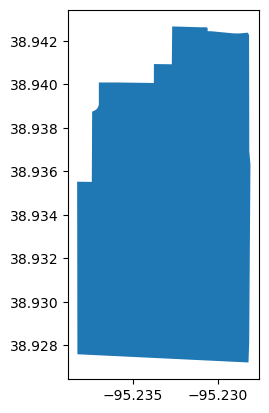

In [3]:
haskell_gdf.plot()

We have a map of the Haskell Campus!

### Create an interactive map

There are lots of different ways to create maps and plots in Python.
Here, we’re going to use a tool called `'hvplot'` and `'geoviews'` to
create an interactive map, including the online `'EsriImagery'` tile
source basemap.

In [4]:
# Plot haskell boundary
haskell_map = haskell_gdf.reset_index().hvplot(
    # Givethe map a descriptive title
    title="Haskell Indian Nations Universty, Lawrence, KS",
    # Add a basemap
    geo=True, tiles='EsriImagery',
    # Change the colors
    fill_color='white', fill_alpha=0.2,
    line_color='skyblue', line_width=5,
    # Change the image size
    frame_width=400, frame_height=400)

# Save the map as a file to put on the web
hv.save(haskell_map, 'haskell.html')

# Display the map
haskell_map

/opt/conda/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

In [5]:
# Search near Haskell for buildings
haskell_buildings = osm.features_from_address(
    "Haskell Indian Nations University, Lawrence, KS, United States",
    tags={"building": True},
    dist=1000
)

haskell_buildings

geometry  \
element_type osmid                                                           
way          68518823    POLYGON ((-95.23971 38.93161, -95.23973 38.931...   
             68518834    POLYGON ((-95.24031 38.93174, -95.24034 38.931...   
             162275740   POLYGON ((-95.24104 38.94232, -95.24032 38.942...   
             171002779   POLYGON ((-95.24041 38.93539, -95.24054 38.935...   
             171002783   POLYGON ((-95.23931 38.93524, -95.23929 38.935...   
...                                                                    ...   
             1290780304  POLYGON ((-95.23208 38.94314, -95.23208 38.943...   
             1303592884  POLYGON ((-95.23924 38.92996, -95.23872 38.929...   
             1313629173  POLYGON ((-95.24374 38.94232, -95.24374 38.942...   
relation     2304135     POLYGON ((-95.23393 38.93883, -95.23393 38.938...   
             2304136     POLYGON ((-95.23450 38.93886, -95.23450 38.938...   

                                                                     nodes  \
element_type osmid                                                           
way          68518823    [823952858, 823952941, 823952969, 823952917, 8...   
             68518834    [823952846, 823952934, 823952887, 823952830, 8...   
             162275740   [1741889746, 1741889750, 1741889748, 174188974...   
             171002779   [1821071486, 8110747820, 8110747819, 811074781...   
             171002783   [1821071477, 1821071473, 1821071476, 182107145...   
...                                                                    ...   
             1290780304  [11967854848, 11967854849, 11967854850, 119678...   
             1303592884  [12072561908, 12072561909, 12072561910, 120725...   
             1313629173  [12159033264, 12159033265, 12159033266, 121590...   
relation     2304135     [[[1834667646, 1834667647, 1834667619, 1834667...   
             2304136     [[[358648520, 1834667667, 1834667654, 18346676...   

                           amenity      building    shelter_type addr:city  \
element_type osmid                                                           
way          68518823      shelter           yes  picnic_shelter       NaN   
             68518834      toilets           yes             NaN       NaN   
             162275740         NaN        retail             NaN  Lawrence   
             171002779         NaN        school             NaN  Lawrence   
             171002783         NaN        school             NaN  Lawrence   
...                            ...           ...             ...       ...   
             1290780304        NaN          shed             NaN       NaN   
             1303592884        NaN  fire_station             NaN       NaN   
             1313629173  fast_food           yes             NaN  Lawrence   
relation     2304135           NaN        school             NaN       NaN   
             2304136           NaN    university             NaN       NaN   

                        addr:housenumber addr:postcode addr:state  \
element_type osmid                                                  
way          68518823                NaN           NaN        NaN   
             68518834                NaN           NaN        NaN   
             162275740              2300         66046         KS   
             171002779              2704         66046         KS   
             171002783              2734         66046         KS   
...                                  ...           ...        ...   
             1290780304              NaN           NaN        NaN   
             1303592884              NaN           NaN        NaN   
             1313629173              707         66046         KS   
relation     2304135                 NaN           NaN        NaN   
             2304136                 NaN           NaN        NaN   

                              addr:street  ... payment:visa  \
element_type osmid                         ...              

<Axes: >

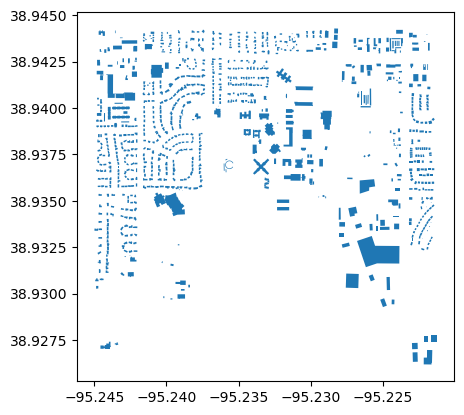

In [6]:
haskell_buildings.plot()

# Let's try another approach with OSM

In [2]:
olc_gdf = osm.geocode_to_gdf(
    'Oglala Lakota College')
olc_gdf

,geometry,bbox_north,bbox_south,bbox_east,bbox_west,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((-102.24535 43.36743, -102.24525 43.3...",43.368987,43.362719,-102.237412,-102.245351,329275749,way,970931215,43.365629,-102.241208,amenity,college,30,0.344995,amenity,Oglala Lakota College,"Oglala Lakota College, BIA 2, Oglala Lakota Co..."


<Axes: >

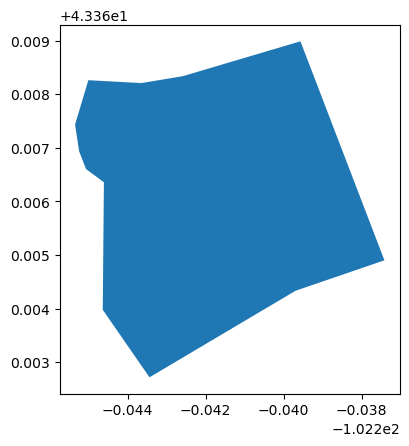

In [6]:
olc_gdf.plot()

In [7]:
# Search for OLC
olc_gdf = osm.features_from_address(
    'Oglala Lakota College, SD, United States',
    {'amenity': ['college']})
olc_gdf

,,amenity,name,geometry,nodes,wikidata
element_type,osmid,,,,,
node,2377246793,college,Oglala Lakota College,POINT (-102.24072 43.36635),NaN,NaN
way,970931215,college,Oglala Lakota College,"POLYGON ((-102.23957 43.36899, -102.23741 43.3...","[8986031620, 8986031621, 8986031622, 898603162...",Q7080082


In [4]:
# Oglala Lakota College (Kyle, SD) - Buildings
college_name = 'Oglala Lakota College'
city_name = 'Kyle'
state_name = 'South Dakota'
tags = {'building':'university', 'name':college_name, 'city':city_name, 'state':state_name}

olc_buildings_gdf = osm.features_from_place(college_name, tags)
olc_buildings_gdf

amenity                                   name  \
element_type osmid                                                        
node         2377246793  college                  Oglala Lakota College   
way          229088180       NaN               Ag and Natural Resources   
             229088181       NaN   Applied Science;Vocational Education   
             229088182       NaN                                    NaN   
             229088183       NaN                              Bookstore   
             229088184       NaN                     Education Building   
             229088185       NaN                      Historical Center   
             229088186   library        Woksape Tipi Library & Archives   
             229088187       NaN                  Multipurpose Building   
             229088188       NaN  Oglala Lakota College Central Offices   
             229088190       NaN                        Pow Wow Grounds   
             970931215   college                  Oglala Lakota College   

                                                                  geometry  \
element_type osmid                                                           
node         2377246793                        POINT (-102.24072 43.36635)   
way          229088180   POLYGON ((-102.24008 43.36692, -102.24030 43.3...   
             229088181   POLYGON ((-102.24032 43.36661, -102.24040 43.3...   
             229088182   POLYGON ((-102.24073 43.36758, -102.24089 43.3...   
             229088183   POLYGON ((-102.24177 43.36660, -102.24177 43.3...   
             229088184   POLYGON ((-102.24003 43.36599, -102.23996 43.3...   
             229088185   POLYGON ((-102.23982 43.36611, -102.23995 43.3...   
             229088186   POLYGON ((-102.24050 43.36703, -102.24068 43.3...   
             229088187   POLYGON ((-102.24236 43.36454, -102.24242 43.3...   
             229088188   POLYGON ((-102.24067 43.36563, -102.24057 43.3...   
             229088190   POLYGON ((-102.23994 43.36492, -102.23986 43.3...   
             970931215   POLYGON ((-102.23957 43.36899, -102.23741 43.3...   

                                                                     nodes  \
element_type osmid                                                           
node         2377246793                                                NaN   
way          229088180   [2377247097, 2377247078, 2377247068, 237724709...   
             229088181   [2377247073, 2377247063, 2377247055, 237724706...   
             229088182   [2377247109, 2377247107, 2377247103, 237724710...   
             229088183   [2377247072, 2377247064, 2377247062, 237724705...   
             229088184   [2377246992, 2377246984, 2377246974, 237724697...   
             229088185   [2377247003, 2377246998, 2377246988, 237724699...   
             229088186   [2377247100, 2377247091, 2377247083, 237724709...   
             229088187   [2377246853, 2377246874, 2377246872, 237724688...   
             229088188   [2377246948, 2377246956, 2377246952, 237724694...   
             229088190   [2377246900, 2377246902, 2377246909, 237724691...   
             970931215   [8986031620, 8986031621, 8986031622, 898603162...   

                           building               operator operator:type  \
element_type osmid                                                         
node         2377246793         NaN                    NaN           NaN   
way          229088180   university                    NaN           NaN   
             229088181   university                    NaN           NaN   
             229088182   university                    NaN           NaN   
             229088183   university                    NaN           NaN   
             229088184   university                    NaN           NaN   
             229088185   university                    NaN           NaN   
             229088186   university  Oglala Lakota College    university   
             229088187   uni

<Axes: >

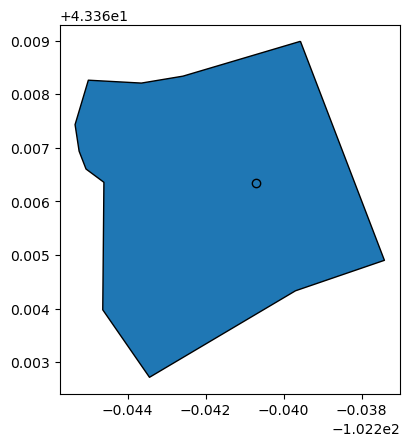

In [9]:
olc_buildings_gdf.plot(edgecolor='black')

In [5]:
# Select out the Pow Wow Grounds from OLC bulidings GDF
olc_pw_gdf = olc_buildings_gdf[olc_buildings_gdf["name"] == "Pow Wow Grounds"]
olc_pw_gdf

,,amenity,name,geometry,nodes,building,operator,operator:type,website,wikidata
element_type,osmid,,,,,,,,,
way,229088190,NaN,Pow Wow Grounds,"POLYGON ((-102.23994 43.36492, -102.23986 43.3...","[2377246900, 2377246902, 2377246909, 237724691...",university,NaN,NaN,NaN,NaN


<Axes: >

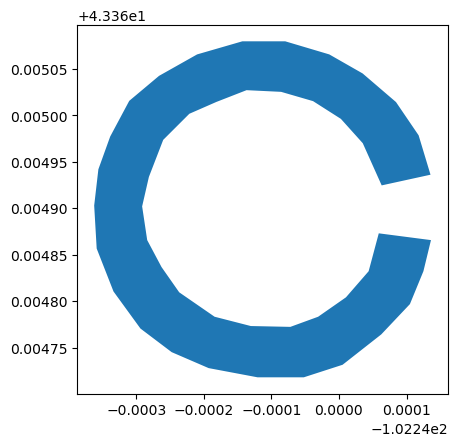

In [6]:
olc_pw_gdf.plot()

In [7]:
# Keep only polygon building geometries
olc_buildings_polygons = olc_buildings_gdf[
    olc_buildings_gdf.geometry.geom_type.isin(
        ["Polygon", "MultiPolygon"]
    )
].copy()

olc_buildings_polygons

amenity                                   name  \
element_type osmid                                                       
way          229088180      NaN               Ag and Natural Resources   
             229088181      NaN   Applied Science;Vocational Education   
             229088182      NaN                                    NaN   
             229088183      NaN                              Bookstore   
             229088184      NaN                     Education Building   
             229088185      NaN                      Historical Center   
             229088186  library        Woksape Tipi Library & Archives   
             229088187      NaN                  Multipurpose Building   
             229088188      NaN  Oglala Lakota College Central Offices   
             229088190      NaN                        Pow Wow Grounds   
             970931215  college                  Oglala Lakota College   

                                                                 geometry  \
element_type osmid                                                          
way          229088180  POLYGON ((-102.24008 43.36692, -102.24030 43.3...   
             229088181  POLYGON ((-102.24032 43.36661, -102.24040 43.3...   
             229088182  POLYGON ((-102.24073 43.36758, -102.24089 43.3...   
             229088183  POLYGON ((-102.24177 43.36660, -102.24177 43.3...   
             229088184  POLYGON ((-102.24003 43.36599, -102.23996 43.3...   
             229088185  POLYGON ((-102.23982 43.36611, -102.23995 43.3...   
             229088186  POLYGON ((-102.24050 43.36703, -102.24068 43.3...   
             229088187  POLYGON ((-102.24236 43.36454, -102.24242 43.3...   
             229088188  POLYGON ((-102.24067 43.36563, -102.24057 43.3...   
             229088190  POLYGON ((-102.23994 43.36492, -102.23986 43.3...   
             970931215  POLYGON ((-102.23957 43.36899, -102.23741 43.3...   

                                                                    nodes  \
element_type osmid                                                          
way          229088180  [2377247097, 2377247078, 2377247068, 237724709...   
             229088181  [2377247073, 2377247063, 2377247055, 237724706...   
             229088182  [2377247109, 2377247107, 2377247103, 237724710...   
             229088183  [2377247072, 2377247064, 2377247062, 237724705...   
             229088184  [2377246992, 2377246984, 2377246974, 237724697...   
             229088185  [2377247003, 2377246998, 2377246988, 237724699...   
             229088186  [2377247100, 2377247091, 2377247083, 237724709...   
             229088187  [2377246853, 2377246874, 2377246872, 237724688...   
             229088188  [2377246948, 2377246956, 2377246952, 237724694...   
             229088190  [2377246900, 2377246902, 2377246909, 237724691...   
             970931215  [8986031620, 8986031621, 8986031622, 898603162...   

                          building               operator operator:type  \
element_type osmid                                                        
way          229088180  university                    NaN           NaN   
             229088181  university                    NaN           NaN   
             229088182  university                    NaN           NaN   
             229088183  university                    NaN           NaN   
             229088184  university                    NaN           NaN   
             229088185  university                    NaN           NaN   
             229088186  university  Oglala Lakota College    university   
             229088187  university                    NaN           NaN   
             229088188  university                    NaN           NaN   
             229088190  university                    NaN           NaN   
             970931215         NaN                    NaN           NaN   

                                                                  website  \
elem

In [13]:
olc_buildings_polygons.hvplot(
    geo=True,
    tiles="EsriImagery",
    line_color="black",
    fill_color="lightgray",
    alpha=0.7,
    width=800,
    height=600,
    title="Oglala Lakota College Buildings"
)

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

In [8]:
# Remove entries where amenity == 'college'
olc_buildings_filtered = olc_buildings_polygons[
    olc_buildings_polygons["amenity"] != "college"
].copy()

olc_buildings_filtered

amenity                                   name  \
element_type osmid                                                       
way          229088180      NaN               Ag and Natural Resources   
             229088181      NaN   Applied Science;Vocational Education   
             229088182      NaN                                    NaN   
             229088183      NaN                              Bookstore   
             229088184      NaN                     Education Building   
             229088185      NaN                      Historical Center   
             229088186  library        Woksape Tipi Library & Archives   
             229088187      NaN                  Multipurpose Building   
             229088188      NaN  Oglala Lakota College Central Offices   
             229088190      NaN                        Pow Wow Grounds   

                                                                 geometry  \
element_type osmid                                                          
way          229088180  POLYGON ((-102.24008 43.36692, -102.24030 43.3...   
             229088181  POLYGON ((-102.24032 43.36661, -102.24040 43.3...   
             229088182  POLYGON ((-102.24073 43.36758, -102.24089 43.3...   
             229088183  POLYGON ((-102.24177 43.36660, -102.24177 43.3...   
             229088184  POLYGON ((-102.24003 43.36599, -102.23996 43.3...   
             229088185  POLYGON ((-102.23982 43.36611, -102.23995 43.3...   
             229088186  POLYGON ((-102.24050 43.36703, -102.24068 43.3...   
             229088187  POLYGON ((-102.24236 43.36454, -102.24242 43.3...   
             229088188  POLYGON ((-102.24067 43.36563, -102.24057 43.3...   
             229088190  POLYGON ((-102.23994 43.36492, -102.23986 43.3...   

                                                                    nodes  \
element_type osmid                                                          
way          229088180  [2377247097, 2377247078, 2377247068, 237724709...   
             229088181  [2377247073, 2377247063, 2377247055, 237724706...   
             229088182  [2377247109, 2377247107, 2377247103, 237724710...   
             229088183  [2377247072, 2377247064, 2377247062, 237724705...   
             229088184  [2377246992, 2377246984, 2377246974, 237724697...   
             229088185  [2377247003, 2377246998, 2377246988, 237724699...   
             229088186  [2377247100, 2377247091, 2377247083, 237724709...   
             229088187  [2377246853, 2377246874, 2377246872, 237724688...   
             229088188  [2377246948, 2377246956, 2377246952, 237724694...   
             229088190  [2377246900, 2377246902, 2377246909, 237724691...   

                          building               operator operator:type  \
element_type osmid                                                        
way          229088180  university                    NaN           NaN   
             229088181  university                    NaN           NaN   
             229088182  university                    NaN           NaN   
             229088183  university                    NaN           NaN   
             229088184  university                    NaN           NaN   
             229088185  university                    NaN           NaN   
             229088186  university  Oglala Lakota College    university   
             229088187  university                    NaN           NaN   
             229088188  university                    NaN           NaN   
             229088190  university                    NaN           NaN   

                                                                  website  \
element_type osmid                                                          
way          229088180                                                NaN   
             229088181                                                NaN   
             229088182                                                NaN   

In [10]:
olc_buildings_filtered.hvplot(
    geo=True,
    tiles="EsriImagery",
    line_color="black",
    fill_color="lightgray",
    alpha=1,
    width=800,
    height=600,
    title="Oglala Lakota College Buildings"
)

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

# OLC campus, Kyle, SD

In [14]:
# OSM way ID from the URL
polygon_osm_id = 1322154594

# Get the polygon from OSM
olc_kyle_polygon_gdf = osm.geocode_to_gdf(
    "W1322154594",
    by_osmid=True
)

olc_kyle_polygon_gdf

,geometry,bbox_north,bbox_south,bbox_east,bbox_west,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((-102.18228 43.42460, -102.18212 43.4...",43.424985,43.42348,-102.179931,-102.182276,328732141,way,1322154594,43.424186,-102.181181,amenity,college,30,0.00005,amenity,Oglala Lakota College - Kyle College Center,"Oglala Lakota College - Kyle College Center, B..."


In [15]:
olc_kyle_polygon = olc_kyle_polygon_gdf.geometry.iloc[0]

In [16]:
olc_kyle_buildings = osm.features_from_polygon(
    olc_kyle_polygon,
    tags={"building": True}
)

olc_kyle_buildings.head()

nodes  \
element_type osmid                                                          
way          166239482  [1777078300, 1777078304, 1777078305, 177707830...   
             166239555  [1777078320, 1777078314, 1777078315, 177707831...   
             759772436  [7097461569, 7097461570, 7097461571, 709746157...   

                       building source  \
element_type osmid                       
way          166239482      yes   Bing   
             166239555      yes   Bing   
             759772436      yes    NaN   

                                                                 geometry  
element_type osmid                                                         
way          166239482  POLYGON ((-102.18211 43.42433, -102.18211 43.4...  
             166239555  POLYGON ((-102.18177 43.42469, -102.18156 43.4...  
             759772436  POLYGON ((-102.18210 43.42408, -102.18204 43.4...

<Axes: >

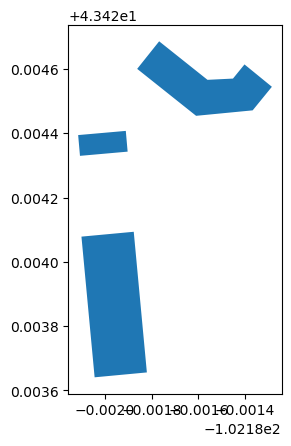

In [17]:
olc_kyle_buildings.plot()

In [19]:
building_layer = olc_kyle_buildings.hvplot(
    geo=True,
    tiles="EsriImagery",
    line_color="black",
    fill_color="blue",
    alpha=1,
    width=800,
    height=600
)

boundary_layer = olc_kyle_polygon_gdf.hvplot(
    geo=True,
    line_color="yellow",
    fill_color=None,
    line_width=4
)

building_layer * boundary_layer

:Overlay
   .WMTS.I      :WMTS   [Longitude,Latitude]
   .Polygons.I  :Polygons   [Longitude,Latitude]
   .Polygons.II :Polygons   [Longitude,Latitude]

# FVSU

In [12]:
fvsu_gdf = osm.geocode_to_gdf(
    'Fort Valley State University')
fvsu_gdf

,geometry,bbox_north,bbox_south,bbox_east,bbox_west,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((-83.90220 32.53398, -83.90218 32.533...",32.542159,32.525196,-83.882058,-83.902203,339530896,way,722635040,32.533663,-83.895046,amenity,university,30,0.406736,amenity,Fort Valley State University,"Fort Valley State University, 1005, State Univ..."


<Axes: >

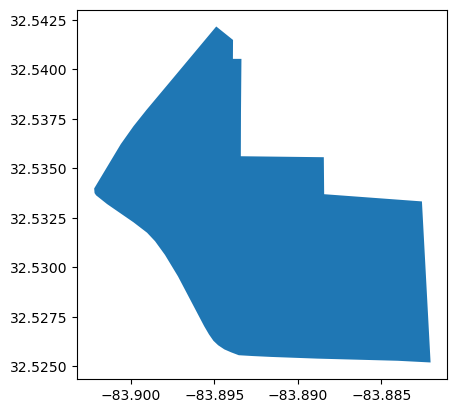

In [13]:
fvsu_gdf.plot()

In [14]:
# Plot FVSU boundary
fvsu_map = fvsu_gdf.reset_index().hvplot(
    # Givethe map a descriptive title
    title="Fort Valley State University, Fort Valley, GA",
    # Add a basemap
    geo=True, tiles='EsriImagery',
    # Change the colors
    fill_color='white', fill_alpha=0.2,
    line_color='skyblue', line_width=5,
    # Change the image size
    frame_width=400, frame_height=400)

# Save the map as a file to put on the web
hv.save(fvsu_map, 'fvsu_map.html')

# Display the map
fvsu_map

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

In [7]:
# FVSU - Buildings
college_name = 'Fort Valley State University'
city_name = 'Fort Valley'
state_name = 'Georgia'
tags = {'building':'university', 'name':college_name, 'city':city_name, 'state':state_name}

fvsu_buildings_gdf = osm.features_from_place(college_name, tags)
fvsu_buildings_gdf

nodes  \
element_type osmid                                                          
way          722635002  [6778464690, 6778464689, 6778464688, 677846468...   
             722635003  [6778464694, 6778464693, 6778464692, 677846469...   
             722635004  [6778464724, 6778464723, 6778464722, 677846472...   
             722635040  [6778464878, 6778464877, 6778464876, 677846487...   
             817860948  [7638135391, 7638135392, 7638135393, 763813539...   
             817860949  [7638135397, 7638135398, 7638135399, 763813540...   
             817860950  [7638135406, 7638135407, 7638135408, 763813540...   
             817860951  [7638135410, 7638135411, 7638135412, 763813541...   
             817860952  [7638135416, 7638135417, 7643779275, 763813541...   
             817860953  [7638135428, 7638135429, 7638135430, 763813543...   
             817860954  [7638135445, 7638135446, 7638135447, 763813544...   
             817860956  [7638135469, 7638135470, 7638135471, 763813547...   
             817860959  [7638150719, 7638150720, 7638150721, 763815072...   
             817860961  [7638150731, 7638150732, 7638150733, 763815073...   
             817860962  [7638150751, 7638150752, 7638150753, 763815075...   
             817860964  [7638150763, 7638150764, 7638150765, 763815076...   
             817860968  [7638150799, 7638150800, 7638150801, 763815080...   
             817860969  [7638150803, 7638150804, 7638150805, 763815080...   
             817860970  [7638150815, 7638150816, 7638150817, 763815081...   
             817860971  [7638150828, 7643779272, 7638150829, 763815083...   
             817880092  [7638305514, 7638305515, 7638305516, 763830551...   
             817880093  [7638305526, 7638305527, 7638305528, 763830552...   
             817880094  [7638305538, 7638305539, 7638305540, 763830554...   
             817880095  [7638305542, 7638305543, 7638305544, 763830554...   
             817880099  [7638311890, 7638311891, 7638311892, 763831189...   
             818481138  [7643723443, 7643723444, 7643723445, 764372344...   
             818481144  [7643723478, 7643723479, 7643723480, 764372348...   
             818488227  [7643782927, 7643782928, 7643782929, 764378293...   

                           amenity    building  \
element_type osmid                               
way          722635002  restaurant  university   
             722635003     library  university   
             722635004         NaN  university   
             722635040  university         NaN   
             817860948         NaN  university   
             817860949         NaN  university   
             817860950         NaN  university   
             817860951         NaN  university   
             817860952         NaN  university   
             817860953         NaN  university   
             817860954         NaN  university   
             817860956         NaN  university   
             817860959         NaN  university   
             817860961         NaN  university   
             817860962         NaN  university   
             817860964         NaN  university   
             817860968         NaN  university   
             817860969         NaN  university   
             817860970         NaN  university   
             817860971         NaN  university   
             817880092         NaN  university   
             817880093         NaN  university   
             817880094         NaN  university   
             817880095         NaN  university   
             817880099         NaN  university   
             818481138         NaN  university   
             818481144         NaN  university   
             818488227         NaN  university   

                                                                     name  \
element_type osmid                                                          
way          722635002                                Food Service Center   
             722635003   

In [9]:
# Select out the Ag building from FVSU bulidings GDF
fvsu_eamb_gdf = fvsu_buildings_gdf[fvsu_buildings_gdf["name"] == "Ellison Agricultural Mechanics Building"]
fvsu_eamb_gdf

,,nodes,amenity,building,name,geometry,operator:type,addr:city,addr:country,addr:housenumber,addr:postcode,addr:state,addr:street,ele,gnis:feature_id,operator,operator:wikidata,wikidata,wikipedia
element_type,osmid,,,,,,,,,,,,,,,,,,
way,817860961,"[7638150731, 7638150732, 7638150733, 763815073...",NaN,university,Ellison Agricultural Mechanics Building,"POLYGON ((-83.89408 32.53580, -83.89397 32.535...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Plot FVSU EAMB boundary
fvsu_eamb_map = fvsu_eamb_gdf.reset_index().hvplot(
    # Givethe map a descriptive title
    title="Fort Valley State University (EAMB), Fort Valley, GA",
    # Add a basemap
    geo=True, tiles='EsriImagery',
    # Change the colors
    fill_color='white', fill_alpha=0.2,
    line_color='skyblue', line_width=5,
    # Change the image size
    frame_width=400, frame_height=400)

# Save the map as a file to put on the web
hv.save(fvsu_eamb_map, 'fvsu_eamb_map.html')

# Display the map
fvsu_eamb_map

/opt/conda/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

In [16]:
# Agness Scott - Buildings
college_name = 'Agnes Scott College'
city_name = 'Decatur'
state_name = 'Georgia'
tags = {'building':'university', 'name':college_name, 'city':city_name, 'state':state_name}

as_buildings_gdf = osm.features_from_place(college_name, tags)
as_buildings_gdf

TypeError: Nominatim could not geocode query 'Agnes Scott College' to a geometry of type (Multi)Polygon

In [ ]:
AS_gdf = osm.geocode_to_gdf(
    'Agnes Scott College')
AS_gdf

TypeError: Nominatim could not geocode query 'Agnes Scott College' to a geometry of type (Multi)Polygon

In [ ]:
import osmnx as ox
import matplotlib.pyplot as plt

# Search OpenStreetMap for Agnes Scott College
place = "Agnes Scott College, Decatur, Georgia, USA"

# Get campus boundary as a GeoDataFrame
asc_gdf = ox.geocode_to_gdf(place)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))

asc_gdf.plot(
    ax=ax,
    edgecolor="black",
    facecolor="none",
    linewidth=2
)

ax.set_title("Agnes Scott College")
ax.set_axis_off()

plt.show()

TypeError: Nominatim could not geocode query 'Agnes Scott College, Decatur, Georgia, USA' to a geometry of type (Multi)Polygon

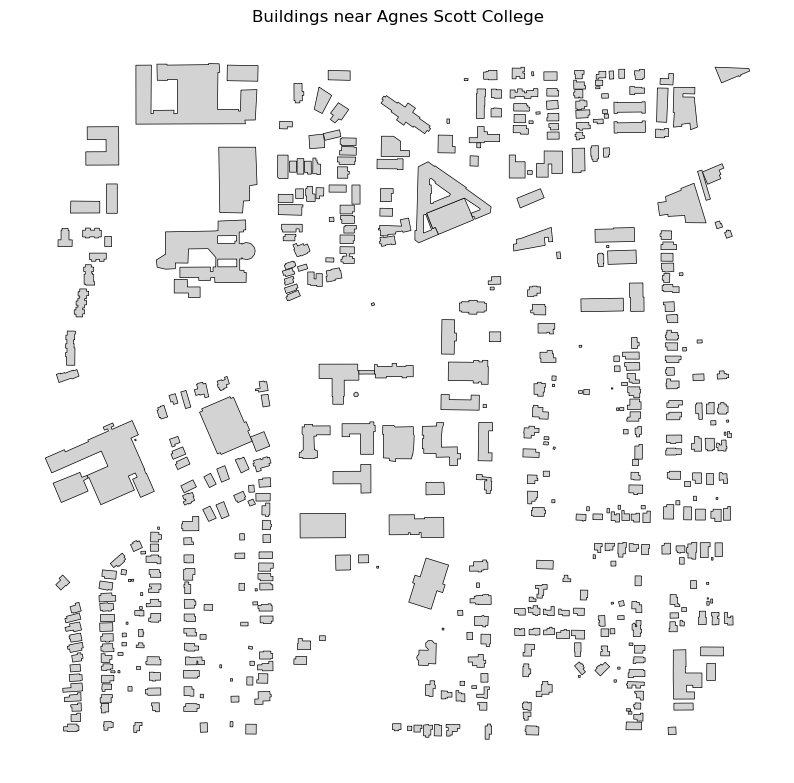

In [ ]:
import osmnx as ox
import matplotlib.pyplot as plt

place = "Agnes Scott College, Decatur, Georgia, USA"

# Get the location as a point
point = ox.geocode(place)

# Get buildings within 500 meters of that point
tags = {"building": True}

buildings = ox.features_from_point(
    point,
    tags=tags,
    dist=500
)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))

buildings.plot(
    ax=ax,
    color="lightgray",
    edgecolor="black",
    linewidth=0.5
)

ax.set_title("Buildings near Agnes Scott College")
ax.set_axis_off()

plt.show()

In [ ]:
import osmnx as ox
import geopandas as gpd
from shapely.geometry import Point

place = "Agnes Scott College, Decatur, Georgia, USA"

# Get campus point
lat, lon = ox.geocode(place)

# Get nearby buildings
buildings = ox.features_from_point(
    (lat, lon),
    tags={"building": True},
    dist=500
)

# Create point GeoDataFrame
college_point = gpd.GeoDataFrame(
    {"name": ["Agnes Scott College"]},
    geometry=[Point(lon, lat)],
    crs="EPSG:4326"
)

# Make interactive map
m = buildings.explore(
    tooltip=False,
    popup=True,
    tiles="CartoDB positron",
    style_kwds={
        "fillColor": "lightgray",
        "color": "black",
        "weight": 1,
        "fillOpacity": 0.6,
    },
    name="Buildings"
)

college_point.explore(
    m=m,
    color="red",
    marker_kwds={"radius": 8},
    tooltip="name",
    name="Agnes Scott College"
)

m

# Making a new assignment (w chat)
Here we'll walk through a hands-on activity using Haskell as the demo campus. Participants are challenged to adapt this workflow to their home campus.

In [1]:
# Import packages
import osmnx as ox
import matplotlib.pyplot as plt

In [2]:
# Choose your campus
place = "Haskell Indian Nations University, Lawrence, Kansas, USA"

In [3]:
# Get campus buildings from OpenStreetMap
tags = {"building": True}

buildings = ox.features_from_place(
    place,
    tags=tags
)

buildings.head()

geometry  \
element_type osmid                                                          
way          172577341  POLYGON ((-95.22917 38.93685, -95.22917 38.937...   
             172577344  POLYGON ((-95.23314 38.93597, -95.23310 38.935...   
             172577350  POLYGON ((-95.23403 38.93802, -95.23376 38.938...   
             172577355  POLYGON ((-95.22933 38.93976, -95.22926 38.939...   
             172577358  POLYGON ((-95.23226 38.93768, -95.23216 38.937...   

                                                                    nodes  \
element_type osmid                                                          
way          172577341  [1834667170, 1834667332, 358648460, 1834667166...   
             172577344  [1834666731, 1834666729, 1834666757, 183466675...   
             172577350  [358648467, 1834667461, 1834667404, 1834667401...   
             172577355  [1834667817, 1834667820, 1834667814, 183466781...   
             172577358  [1834928534, 1834928532, 11147152489, 18346674...   

                          building  ele gnis:feature_id  \
element_type osmid                                        
way          172577341  university  259         2510648   
             172577344  university  263         2510649   
             172577350  university  265         2510650   
             172577355         yes  267         2510651   
             172577358  university  268         2510652   

                                         name  \
element_type osmid                              
way          172577341    American Horse Hall   
             172577344           Blalock Hall   
             172577350        Blue Eagle Hall   
             172577355  Coffin Sports Complex   
             172577358            Curtis Hall   

                                                 operator        leisure  \
element_type osmid                                                         
way          172577341  Haskell Indian Nations University            NaN   
             172577344  Haskell Indian Nations University            NaN   
             172577350  Haskell Indian Nations University            NaN   
             172577355  Haskell Indian Nations University  sports_centre   
             172577358  Haskell Indian Nations University            NaN   

                       addr:state source tourism amenity ways type  
element_type osmid                                                  
way          172577341        NaN    NaN     NaN     NaN  NaN  NaN  
             172577344        NaN    NaN     NaN     NaN  NaN  NaN  
             172577350        NaN    NaN     NaN     NaN  NaN  NaN  
             172577355        NaN    NaN     NaN     NaN  NaN  NaN  
             172577358        NaN    NaN     NaN     NaN  NaN  NaN

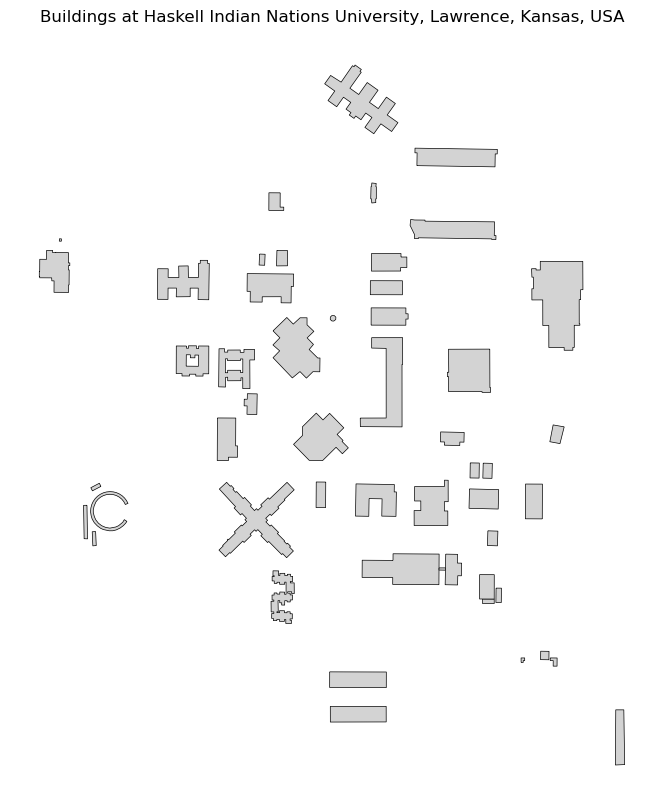

In [4]:
# Plot the buildings
fig, ax = plt.subplots(figsize=(10, 10))

buildings.plot(
    ax=ax,
    color="lightgray",
    edgecolor="black",
    linewidth=0.5
)

ax.set_title(f"Buildings at {place}")
ax.set_axis_off()

plt.show()

In [7]:
buildings.hvplot(
    geo=True,
    tiles="EsriImagery",
    line_color="black",
    fill_color="lightgray",
    alpha=0.7,
    width=800,
    height=600,
    title=f"Buildings at {place}"
)

/opt/conda/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

<Axes: >

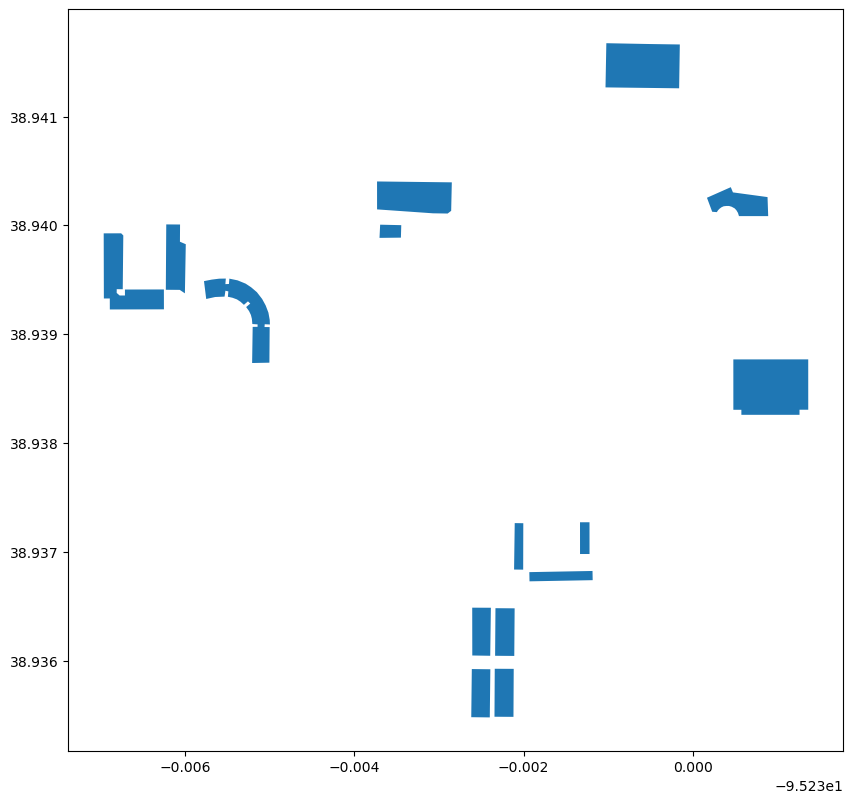

In [8]:
# Try finding parking areas
tags = {"amenity": "parking"}

parking = ox.features_from_place(
    place,
    tags=tags
)

parking.plot(figsize=(10, 10))

<Axes: >

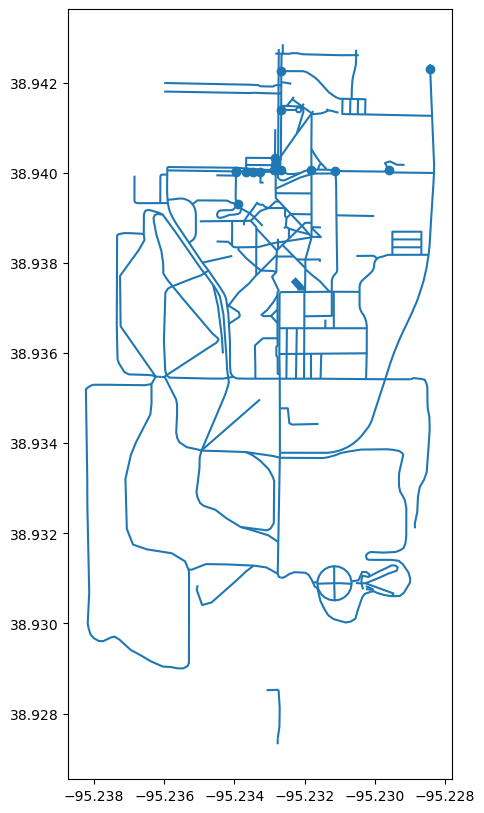

In [9]:
# Try finding roads and paths
tags = {"highway": True}

paths = ox.features_from_place(
    place,
    tags=tags
)

paths.plot(figsize=(10, 10))

# Repeat this workflow for Agnes Scott
Let's repeat the Haskell workflow for ASC. Note ASC has some challenges in OSM and is saved as a point not a polygon. This changes how we'll search for this campus.

In [10]:
# Define place
place = "Agnes Scott College, Decatur, Georgia, USA"

In [13]:
import osmnx as ox

place = "Agnes Scott College, Decatur, Georgia, USA"

# Geocode the campus to a point
point = ox.geocode(place)

# Search for buildings within 500 meters of that point
tags = {"building": True}

buildings = ox.features_from_point(
    point,
    tags=tags,
    dist=500
)

buildings.head()

amenity  \
element_type osmid                  
way          40803848         NaN   
             40897634      police   
             43300138         NaN   
             43873108         NaN   
             48296311  restaurant   

                                                                geometry  \
element_type osmid                                                         
way          40803848  POLYGON ((-84.29410 33.76524, -84.29410 33.765...   
             40897634  POLYGON ((-84.29654 33.76822, -84.29664 33.768...   
             43300138  POLYGON ((-84.29574 33.77312, -84.29553 33.773...   
             43873108  POLYGON ((-84.29559 33.77322, -84.29559 33.773...   
             48296311  POLYGON ((-84.29473 33.77173, -84.29452 33.771...   

                                                                   nodes  \
element_type osmid                                                         
way          40803848  [496120097, 1018406280, 1018406312, 1018406359...   
             40897634  [497811879, 497811882, 497811868, 660541772, 4...   
             43300138  [544047782, 544047787, 544047793, 544047800, 5...   
             43873108  [557262411, 557262415, 557262420, 557262430, 5...   
             48296311  [5646599322, 613621940, 613621941, 613621942, ...   

                      building                       name building:levels  \
element_type osmid                                                          
way          40803848      yes                        NaN             NaN   
             40897634      yes  Agnes Scott Public Safety             NaN   
             43300138      yes         Executive Building             NaN   
             43873108      yes                        NaN             NaN   
             48296311      yes                    Revival             NaN   

                      roof:levels roof:shape addr:city addr:housenumber  ...  \
element_type osmid                                                       ...   
way          40803848         NaN        NaN       NaN              NaN  ...   
             40897634         NaN        NaN       NaN              NaN  ...   
             43300138         NaN        NaN       NaN              NaN  ...   
             43873108         NaN        NaN       NaN              NaN  ...   
             48296311         NaN        NaN   Decatur              129  ...   

                      layer social_facility social_facility:for parking note  \
element_type osmid                                                             
way          40803848   NaN             NaN                 NaN     NaN  NaN   
             40897634   NaN             NaN                 NaN     NaN  NaN   
             43300138   NaN             NaN                 NaN     NaN  NaN   
             43873108   NaN             NaN                 NaN     NaN  NaN   
             48296311   NaN             NaN                 NaN     NaN  NaN   

                      smoking access  fee ways type  
element_type osmid                                   
way          40803848     NaN    NaN  NaN  NaN  NaN  
             40897634     NaN    NaN  NaN  NaN  NaN  
             43300138     NaN    NaN  NaN  NaN  NaN  
             43873108     NaN    NaN  NaN  NaN  NaN  
             48296311     NaN    NaN  NaN  NaN  NaN  

[5 rows x 42 columns]

In [14]:
buildings.hvplot(
    geo=True,
    tiles="EsriImagery",
    line_color="black",
    fill_color="lightgray",
    alpha=0.7,
    width=800,
    height=600,
    title="Buildings near Agnes Scott College"
)

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

In [15]:
place = "Colorado State University, Fort Collins, Colorado, USA"

In [16]:
# Get campus buildings from OpenStreetMap
tags = {"building": True}

buildings = ox.features_from_place(
    place,
    tags=tags
)

buildings.head()

geometry  \
element_type osmid                                                           
node         3894512815                        POINT (-105.10630 40.57721)   
             8835191334                        POINT (-105.07392 40.56948)   
way          54896127    POLYGON ((-105.08352 40.56861, -105.08352 40.5...   
             103927703   POLYGON ((-105.08199 40.57780, -105.08199 40.5...   
             104141391   POLYGON ((-105.08200 40.57686, -105.08200 40.5...   

                         amenity                         name operator  \
element_type osmid                                                       
node         3894512815      NaN  CSU Housing Services Center      NaN   
             8835191334      NaN                     UCA East      NaN   
way          54896127    parking   Lake Street Parking Garage      NaN   
             103927703       NaN                  Ammons Hall      NaN   
             104141391       NaN                TILT Building      NaN   

                        building addr:city addr:housenumber addr:state  \
element_type osmid                                                       
node         3894512815      yes       NaN              NaN        NaN   
             8835191334      yes       NaN              NaN        NaN   
way          54896127        yes       NaN              NaN        NaN   
             103927703       yes       NaN              NaN        NaN   
             104141391       yes       NaN              NaN        NaN   

                        addr:street website  ... building:material  \
element_type osmid                           ...                     
node         3894512815         NaN     NaN  ...               NaN   
             8835191334         NaN     NaN  ...               NaN   
way          54896127           NaN     NaN  ...               NaN   
             103927703          NaN     NaN  ...               NaN   
             104141391          NaN     NaN  ...               NaN   

                        roof:height shelter_type second_hand faculty  \
element_type osmid                                                     
node         3894512815         NaN          NaN         NaN     NaN   
             8835191334         NaN          NaN         NaN     NaN   
way          54896127           NaN          NaN         NaN     NaN   
             103927703          NaN          NaN         NaN     NaN   
             104141391          NaN          NaN         NaN     NaN   

                        min_level roof:orientation ways fixme type  
element_type osmid                                                  
node         3894512815       NaN              NaN  NaN   NaN  NaN  
             8835191334       NaN              NaN  NaN   NaN  NaN  
way          54896127         NaN              NaN  NaN   NaN  NaN  
             103927703        NaN              NaN  NaN   NaN  NaN  
             104141391        NaN              NaN  NaN   NaN  NaN  

[5 rows x 50 columns]

In [17]:
buildings.hvplot(
    geo=True,
    tiles="EsriImagery",
    line_color="black",
    fill_color="lightgray",
    alpha=0.7,
    width=800,
    height=600,
    title="Buildings near CSU"
)

ValueError: The GeopandasInterface can only read dataframes which share a common geometry type

In [ ]:
# Search for CSU
csu_gdf = osm.features_from_address(
    'Colorado State University, Fort Collins, CO, United States',
    {'amenity': ['university']})
csu_gdf

,,geometry,nodes,amenity,building,check_date,name,ways,contact:website,short_name,type,wikidata,wikipedia
element_type,osmid,,,,,,,,,,,,
way,203375392,"POLYGON ((-105.07966 40.57210, -105.07966 40.5...","[2133865543, 2383728691, 2383728707, 238373259...",university,public,2025-11-12,General Services,NaN,NaN,NaN,NaN,NaN,NaN
relation,8539568,"MULTIPOLYGON (((-105.10281 40.57868, -105.1007...","[[[8993897518, 9198191072, 8994516033, 2382933...",university,NaN,NaN,Colorado State University,"[208623822, 971723614, 386388522, 386113581, 9...",https://www.colostate.edu/,CSU,multipolygon,Q1111640,en:Colorado State University


In [20]:
csu_gdf.hvplot(
    geo=True,
    tiles="EsriImagery",
    line_color="black",
    fill_color="lightgray",
    alpha=0.7,
    width=800,
    height=600,
    title="CSU Campus Map"
)

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

In [24]:
# Search for WVSU
wvsu_gdf = osm.features_from_address(
    'West Virginia State University, Charleston, WV, United States',
    {'amenity': ['university']})
wvsu_gdf

InsufficientResponseError: No data elements in server response. Check log and query location/tags.

In [26]:
import osmnx as ox

place = "west virginia state university, Institute, WV, United States"

point = ox.geocode(place)

tags = {"building": True}

wvsu_buildings = ox.features_from_point(
    point,
    tags=tags,
    dist=750
)

wvsu_buildings.head()

InsufficientResponseError: Nominatim could not geocode query 'west virginia state university, Institute, WV, United States'

In [27]:
place = "West Virginia State University, Institute, WV, United States"
point = ox.geocode(place)

tags = {"building": True}

campus_features = ox.features_from_point(
    point,
    tags=tags,
    dist=750
)

InsufficientResponseError: Nominatim could not geocode query 'West Virginia State University, Institute, WV, United States'

In [28]:
import osmnx as ox

# Approximate center of West Virginia State University
wvsu_point = (38.3796, -81.7654)  # lat, lon

tags = {"building": True}

wvsu_buildings = ox.features_from_point(
    wvsu_point,
    tags=tags,
    dist=750
)

wvsu_buildings.head()

geometry  \
element_type osmid                                                          
way          548655496  POLYGON ((-81.76471 38.38306, -81.76488 38.383...   
             548655497  POLYGON ((-81.76534 38.38289, -81.76533 38.382...   
             548655498  POLYGON ((-81.76405 38.38260, -81.76363 38.382...   
             548655499  POLYGON ((-81.76392 38.38153, -81.76393 38.381...   
             548655500  POLYGON ((-81.76572 38.38136, -81.76565 38.381...   

                                                                    nodes  \
element_type osmid                                                          
way          548655496  [5300304230, 5300304231, 8276668075, 530030423...   
             548655497  [5300304242, 5300304243, 8246383052, 530030424...   
             548655498  [5300304262, 5300304263, 8238301127, 823830112...   
             548655499  [5300304273, 5300304274, 5300304275, 530030427...   
             548655500  [5300304299, 8248581592, 8248581594, 530030430...   

                          building                  name  amenity  \
element_type osmid                                                  
way          548655496  university          Wallace Hall      NaN   
             548655497  university          Ferrell Hall      NaN   
             548655498  university          Hamblin Hall      NaN   
             548655499         yes  Drain-Jordan Library  library   
             548655500  university   Keith Scholars Hall      NaN   

                                              operator operator:type  \
element_type osmid                                                     
way          548655496                             NaN           NaN   
             548655497                             NaN           NaN   
             548655498                             NaN           NaN   
             548655499  West Virginia State University    university   
             548655500                             NaN           NaN   

                                              website   wikidata layer  ...  \
element_type osmid                                                      ...   
way          548655496                            NaN        NaN   NaN  ...   
             548655497                            NaN        NaN   NaN  ...   
             548655498                            NaN        NaN   NaN  ...   
             548655499  https://library.wvstateu.edu/  Q96609896   NaN  ...   
             548655500                            NaN        NaN     1  ...   

                       source building:levels denomination religion  \
element_type osmid                                                    
way          548655496    NaN             NaN          NaN      NaN   
             548655497    NaN             NaN          NaN      NaN   
             548655498    NaN             NaN          NaN      NaN   
             548655499    NaN             NaN          NaN      NaN   
             548655500    NaN             NaN          NaN      NaN   

                       building:material capacity ways building:colour type  \
element_type osmid                                                            
way          548655496               NaN      NaN  NaN             NaN  NaN   
             548655497               NaN      NaN  NaN             NaN  NaN   
             548655498               NaN      NaN  NaN             NaN  NaN   
             548655499               NaN      NaN  NaN             NaN  NaN   
             548655500               NaN      NaN  NaN             NaN  NaN   

                       image  
element_type osmid            
way          548655496   NaN  
             548655497   NaN  
             548655498   NaN  
             548655499   NaN  
             548655500   NaN  

[5 rows x 30 columns]

In [29]:
wvsu_buildings.hvplot(
    geo=True,
    tiles="EsriImagery",
    line_color="black",
    fill_color="lightgray",
    alpha=0.7,
    width=800,
    height=600,
    title="Buildings near West Virginia State University"
)

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

In [30]:
# Get paths, sidewalks, roads, and other route features near WVSU
tags = {"highway": True}

wvsu_paths = ox.features_from_point(
    wvsu_point,
    tags=tags,
    dist=750
)

wvsu_paths.head()

highway traffic_signals  \
element_type osmid                                         
node         155346276   traffic_signals          signal   
             7689067931             stop             NaN   
             7689067939         give_way             NaN   
             8246382826         crossing             NaN   
             8246382948         crossing             NaN   

                                           geometry crossing access direction  \
element_type osmid                                                              
node         155346276   POINT (-81.76561 38.38380)      NaN    NaN       NaN   
             7689067931  POINT (-81.77001 38.38607)      NaN    NaN       NaN   
             7689067939  POINT (-81.77134 38.38601)      NaN    NaN       NaN   
             8246382826  POINT (-81.76678 38.37933)      NaN    NaN       NaN   
             8246382948  POINT (-81.76874 38.37950)   marked    NaN       NaN   

                        material design lamp_mount lamp_type  ... cycleway  \
element_type osmid                                            ...            
node         155346276       NaN    NaN        NaN       NaN  ...      NaN   
             7689067931      NaN    NaN        NaN       NaN  ...      NaN   
             7689067939      NaN    NaN        NaN       NaN  ...      NaN   
             8246382826      NaN    NaN        NaN       NaN  ...      NaN   
             8246382948      NaN    NaN        NaN       NaN  ...      NaN   

                         lit tiger:name_base_2 source motor_vehicle incline  \
element_type osmid                                                            
node         155346276   NaN               NaN    NaN           NaN     NaN   
             7689067931  NaN               NaN    NaN           NaN     NaN   
             7689067939  NaN               NaN    NaN           NaN     NaN   
             8246382826  NaN               NaN    NaN           NaN     NaN   
             8246382948  NaN               NaN    NaN           NaN     NaN   

                        handrail step_count tactile_paving covered  
element_type osmid                                                  
node         155346276       NaN        NaN            NaN     NaN  
             7689067931      NaN        NaN            NaN     NaN  
             7689067939      NaN        NaN            NaN     NaN  
             8246382826      NaN        NaN            NaN     NaN  
             8246382948      NaN        NaN            NaN     NaN  

[5 rows x 60 columns]

In [31]:
wvsu_paths.hvplot(
    geo=True,
    tiles="EsriImagery",
    line_color="yellow",
    line_width=3,
    width=800,
    height=600,
    title="Paths and roads near West Virginia State University"
)

ValueError: The GeopandasInterface can only read dataframes which share a common geometry type

In [32]:
# Keep only line geometry features
wvsu_path_lines = wvsu_paths[
    wvsu_paths.geometry.geom_type.isin(["LineString", "MultiLineString"])
].copy()

In [33]:
wvsu_path_lines.hvplot(
    geo=True,
    tiles="EsriImagery",
    line_color="yellow",
    line_width=3,
    width=800,
    height=600,
    title="Paths and roads near West Virginia State University"
)

:Overlay
   .WMTS.I :WMTS   [Longitude,Latitude]
   .Path.I :Path   [Longitude,Latitude]

# Look at TOCC and SCAC


In [34]:
# Approximate center of Tohono O'odham Community College main campus
tocc_point = (31.9899, -111.7155)  # lat, lon

In [35]:
tags = {"building": True}

tocc_buildings = ox.features_from_point(
    tocc_point,
    tags=tags,
    dist=750
)

In [36]:
tags = {"highway": True}

tocc_paths = ox.features_from_point(
    tocc_point,
    tags=tags,
    dist=750
)

# Keep only line geometry features
tocc_path_lines = tocc_paths[
    tocc_paths.geometry.geom_type.isin(["LineString", "MultiLineString"])
].copy()

In [37]:
building_layer = tocc_buildings.hvplot(
    geo=True,
    tiles="EsriImagery",
    line_color="black",
    fill_color="lightgray",
    alpha=0.6,
    width=800,
    height=600
)

path_layer = tocc_path_lines.hvplot(
    geo=True,
    line_color="yellow",
    line_width=3
)

building_layer * path_layer

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]
   .Path.I     :Path   [Longitude,Latitude]

In [40]:
# Campus locations
campuses = pd.DataFrame({
    "college": [
        "Oglala Lakota College",
        "MSU Denver",
        "Haskell Indian Nations University",
        "Colorado State University",
        "Fort Valley State University",
        "Agnes Scott College",
        "UW Madison",
        "West Virginia State University",
        "Tohono O'odham Community College"
    ],
    "lat": [
        43.3337,
        39.7451,
        38.9403,
        40.5734,
        32.5344,
        33.7689,
        43.0766,
        38.3796,
        31.9899
    ],
    "lon": [
        -102.5500,
        -105.0077,
        -95.2305,
        -105.0865,
        -83.8961,
        -84.2941,
        -89.4125,
        -81.7654,
        -111.7155
    ]
})

In [41]:
# Convert to a GeoDataFrame
campus_gdf = gpd.GeoDataFrame(
    campuses,
    geometry=gpd.points_from_xy(
        campuses["lon"],
        campuses["lat"]
    ),
    crs="EPSG:4326"
)

campus_gdf

,college,lat,lon,geometry
0,Oglala Lakota College,43.3337,-102.5500,POINT (-102.55000 43.33370)
1,MSU Denver,39.7451,-105.0077,POINT (-105.00770 39.74510)
2,Haskell Indian Nations University,38.9403,-95.2305,POINT (-95.23050 38.94030)
3,Colorado State University,40.5734,-105.0865,POINT (-105.08650 40.57340)
4,Fort Valley State University,32.5344,-83.8961,POINT (-83.89610 32.53440)
5,Agnes Scott College,33.7689,-84.2941,POINT (-84.29410 33.76890)
6,UW Madison,43.0766,-89.4125,POINT (-89.41250 43.07660)
7,West Virginia State University,38.3796,-81.7654,POINT (-81.76540 38.37960)
8,Tohono O'odham Community College,31.9899,-111.7155,POINT (-111.71550 31.98990)


In [42]:
# Interactive CONUS map
campus_gdf.hvplot(
    geo=True,
    tiles="CartoDB positron",
    size=140,
    color="red",
    hover_cols=["college"],
    width=950,
    height=600,
    title="Partner Colleges Across the Continental United States",
    xlim=(-125, -66),
    ylim=(24, 50)
)

ValueError: CartoDB positron tiles not recognized, must be one of: ['CartoDark', 'CartoEco', 'CartoLight', 'CartoMidnight', 'EsriAntarcticImagery', 'EsriArcticImagery', 'EsriArcticOceanBase', 'EsriArcticOceanReference', 'EsriDelormeWorldBaseMap', 'EsriImagery', 'EsriNatGeo', 'EsriOceanBase', 'EsriOceanReference', 'EsriReference', 'EsriTerrain', 'EsriUSATopo', 'EsriWorldBoundariesAndPlaces', 'EsriWorldBoundariesAndPlacesAlternate', 'EsriWorldDarkGrayBase', 'EsriWorldDarkGrayReference', 'EsriWorldHillshade', 'EsriWorldHillshadeDark', 'EsriWorldLightGrayBase', 'EsriWorldLightGrayReference', 'EsriWorldNavigationCharts', 'EsriWorldPhysical', 'EsriWorldShadedRelief', 'EsriWorldStreetMap', 'EsriWorldTopo', 'EsriWorldTransportation', 'OSM', 'OpenTopoMap'] or a tile object

In [43]:
campus_gdf.hvplot(
    geo=True,
    tiles="CartoLight",
    size=140,
    color="red",
    hover_cols=["college"],
    width=950,
    height=600,
    title="Partner Colleges Across the Continental United States",
    xlim=(-125, -66),
    ylim=(24, 50)
)

:Overlay
   .WMTS.I   :WMTS   [Longitude,Latitude]
   .Points.I :Points   [Longitude,Latitude]   (college)

# WVSU
This one has been tricky to map.

In [4]:
# WVSU OSM way ID
wvsu_osm_id = 386835483

# OSMnx needs way IDs formatted as "W" + the ID
wvsu_boundary = osm.geocode_to_gdf(
    "W386835483",
    by_osmid=True
)

wvsu_boundary

,geometry,bbox_north,bbox_south,bbox_east,bbox_west,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((-81.77346 38.37683, -81.76883 38.374...",38.384622,38.374299,-81.762855,-81.773455,339771109,way,386835483,38.379391,-81.76806,amenity,university,30,0.414537,amenity,West Virginia State University,"West Virginia State University, Faculty Circle..."


In [5]:
wvsu_boundary.hvplot(
    geo=True,
    tiles="EsriImagery",
    line_color="yellow",
    fill_color=None,
    line_width=4,
    width=800,
    height=600,
    title="West Virginia State University Boundary"
)

/opt/conda/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

In [7]:
# Get the campus polygon
wvsu_polygon = wvsu_boundary.geometry.iloc[0]

# Query buildings inside the polygon
wvsu_buildings = osm.features_from_polygon(
    wvsu_polygon,
    tags={"building": True}
)

wvsu_buildings.head()

geometry  \
element_type osmid                                                          
way          548655496  POLYGON ((-81.76471 38.38306, -81.76488 38.383...   
             548655497  POLYGON ((-81.76534 38.38289, -81.76533 38.382...   
             548655498  POLYGON ((-81.76405 38.38260, -81.76363 38.382...   
             548655499  POLYGON ((-81.76392 38.38153, -81.76393 38.381...   
             548655500  POLYGON ((-81.76572 38.38136, -81.76565 38.381...   

                                                                    nodes  \
element_type osmid                                                          
way          548655496  [5300304230, 5300304231, 8276668075, 530030423...   
             548655497  [5300304242, 5300304243, 8246383052, 530030424...   
             548655498  [5300304262, 5300304263, 8238301127, 823830112...   
             548655499  [5300304273, 5300304274, 5300304275, 530030427...   
             548655500  [5300304299, 8248581592, 8248581594, 530030430...   

                          building                  name  amenity  \
element_type osmid                                                  
way          548655496  university          Wallace Hall      NaN   
             548655497  university          Ferrell Hall      NaN   
             548655498  university          Hamblin Hall      NaN   
             548655499         yes  Drain-Jordan Library  library   
             548655500  university   Keith Scholars Hall      NaN   

                                              operator operator:type  \
element_type osmid                                                     
way          548655496                             NaN           NaN   
             548655497                             NaN           NaN   
             548655498                             NaN           NaN   
             548655499  West Virginia State University    university   
             548655500                             NaN           NaN   

                                              website   wikidata layer  \
element_type osmid                                                       
way          548655496                            NaN        NaN   NaN   
             548655497                            NaN        NaN   NaN   
             548655498                            NaN        NaN   NaN   
             548655499  https://library.wvstateu.edu/  Q96609896   NaN   
             548655500                            NaN        NaN     1   

                       leisure source  
element_type osmid                     
way          548655496     NaN    NaN  
             548655497     NaN    NaN  
             548655498     NaN    NaN  
             548655499     NaN    NaN  
             548655500     NaN    NaN

In [8]:
building_layer = wvsu_buildings.hvplot(
    geo=True,
    tiles="EsriImagery",
    line_color="black",
    fill_color="lightgray",
    alpha=0.7,
    width=800,
    height=600
)

boundary_layer = wvsu_boundary.hvplot(
    geo=True,
    line_color="yellow",
    fill_color=None,
    line_width=4
)

building_layer * boundary_layer

:Overlay
   .WMTS.I      :WMTS   [Longitude,Latitude]
   .Polygons.I  :Polygons   [Longitude,Latitude]
   .Polygons.II :Polygons   [Longitude,Latitude]

In [9]:
wvsu_paths = osm.features_from_polygon(
    wvsu_polygon,
    tags={"highway": True}
)

# Keep only line geometries for hvplot
wvsu_path_lines = wvsu_paths[
    wvsu_paths.geometry.geom_type.isin(["LineString", "MultiLineString"])
].copy()

In [10]:
path_layer = wvsu_path_lines.hvplot(
    geo=True,
    line_color="orange",
    line_width=3
)

building_layer * path_layer * boundary_layer

:Overlay
   .WMTS.I      :WMTS   [Longitude,Latitude]
   .Polygons.I  :Polygons   [Longitude,Latitude]
   .Path.I      :Path   [Longitude,Latitude]
   .Polygons.II :Polygons   [Longitude,Latitude]